In [38]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import fftconvolve, spectrogram, freqz
from tqdm import tqdm
import scipy.stats as stats
from matplotlib import ticker

# --- Path & Custom Library Setup ---*
sys.path.append('../../')
from adaptive_notch_filter_functions import (
    JammerSignalProcessor,
    GoldCodeGenerator
)


# Three steps to an adaptive Notch Filter.
## For each step there is an accompanying visualisation plot
#### The theoretically best filter (with infinite computing power) would obtain a 100% correlation to the original signal.
#### To obtain a GNSS L1 Gold Code signal, we aim to have a correlation of at least 70\%. 
#### The beneath structures obtain >90% on a LFM Chirp Jammer, 10.000x (80 dB) louder than the Signal of Interest. 
#### Parameters have not yet been optimized. 

# 1. Filtering a single chunk
#### The chunk refers to a slice of the entire signal, with a given length. Does not need to start in-phase.

In [39]:
# -------------------------------------------------------------------------
# SIMULATION SETUP
# -------------------------------------------------------------------------
# Timing and Frequency Configuration
f_samplerate    = 2.56e6
sweep_time      = 10e-3
main_lobe_width = 1.253e6
jammer_freqs    = [-main_lobe_width, main_lobe_width]
chirp_rate      = (jammer_freqs[1] - jammer_freqs[0]) / sweep_time
jitter_std      = 1e3
jammer_amp_dB   = 80
taper_ratio     = 0.1

# Vectors
N_samples = int(1.0 * f_samplerate)
t_vec     = np.arange(N_samples) / f_samplerate

# Generate the Signal of Interest (GNSS with PRN = 27)
gen = GoldCodeGenerator(PRN=27, samp_rate=f_samplerate, vectorLength=N_samples)
signal_of_interest = gen.process()  

# Generate LFM Jamming signal (Chirp Jammer)
jammer = GoldCodeGenerator.create_linear_FM_signal(
    jammer_freqs, 
    t_vec, 
    f_samplerate, 
    amplitude   = 10**(jammer_amp_dB/20), 
    chirp_rate  = chirp_rate, 
    jitter_std  = jitter_std, 
    taper_ratio = taper_ratio
)

# Observe the combined signal
signal = signal_of_interest + jammer

print(f"Jammer parameters: \nChirp Rate: {chirp_rate:.2f} Hz/s\nFrequency Range: {jammer_freqs[0]:.2f} to {jammer_freqs[1]:.2f} Hz")

# -------------------------------------------------------------------------
# 1. CHUNKING AND PARAMETERIZATION
# -------------------------------------------------------------------------
acquisition_chunk_size = int(0.5 * f_samplerate) 
start_idx = 264532 # Selected window offset
taper_sec = 0.0002 # 200µs Tukey windowing

# Extract chunk for analysis
acquisition_chunk = signal[start_idx : start_idx + acquisition_chunk_size]

# Parameterization (Includes Sub-Bin Peak Detection & Drift Refinement)
params = JammerSignalProcessor.estimate_jammer_physics(
    acquisition_chunk, 
    f_samplerate, 
    start_idx, 
    taper_sec, 
    spectrogram_nperseg=1024, 
    spectrogram_overlap=819
)

# -------------------------------------------------------------------------
# 2. DESIGNING AN ADAPTIVE NOTCH FILTER
# -------------------------------------------------------------------------
N_taps, notch_width, transition_width_Hz = JammerSignalProcessor.calculate_filter_parameters(
    params.chirp_rate, 
    f_samplerate,
    params.bandwidth,
    notch_width_percentage=0.2,
    transition_width_multiplier=0.1,
    max_phase=1.17
)

attenuation_dB = 81

h = JammerSignalProcessor.dc_firwin_filter(N_taps, f_samplerate, notch_width, attenuation_dB, transition_width_Hz)
group_delay = (N_taps - 1) // 2

print(f"Filter Ready: {N_taps} Taps | Group Delay: {group_delay} samples")

# -------------------------------------------------------------------------
# 3. PROCESSING: Continuous Overlap-Add (OLA) Loop
# -------------------------------------------------------------------------

chunk_size = int(0.02 * f_samplerate) # 20ms processing blocks
tail_length   = N_taps - 1
output_signal = np.zeros(N_samples + tail_length, dtype=complex)


for i_start in tqdm(range(0, N_samples, chunk_size)):
    i_end = min(i_start + chunk_size, N_samples)
    current_length = i_end - i_start
    if current_length == 0: break
    
    full_convolution_length = current_length + tail_length
    signal_chunk  = signal[i_start : i_end]

    # --- Downconversion LO ---
    t_local = (i_start + np.arange(current_length)) / f_samplerate
    LO_down, _ = JammerSignalProcessor.LO_calculator(   
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_local, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # --- Upconversion LO with Group-Delay Compensation ---
    t_up = (i_start - group_delay + np.arange(full_convolution_length)) / f_samplerate
    _, LO_up = JammerSignalProcessor.LO_calculator(
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_up, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # Core DSP Pipeline
    signal_downconverted = signal_chunk * LO_down

    # Filter (Expanding to Full length to capture the ringing tail)
    signal_filtered = fftconvolve(signal_downconverted, h, mode = "full")
    processed_block = signal_filtered * LO_up

    # Overlap-Add: Tail from current chunk sums with the start of the next
    output_signal[i_start : i_start + full_convolution_length] += processed_block
    

# -------------------------------------------------------------------------
# 5. VALIDATION: Final Signal Reconstruction
# -------------------------------------------------------------------------
# Align recovered signal by removing the filter's physical delay
recovered_signal = output_signal[group_delay : N_samples + group_delay]

# Discard edges to avoid filter transient artifacts
safety_margin = N_taps * 2
reference_clean = signal_of_interest[safety_margin : N_samples - safety_margin]
reference_filtered  = recovered_signal[safety_margin : N_samples - safety_margin]

max_correlation = JammerSignalProcessor.analyze_correlation(reference_clean, reference_filtered)

print("========================================================")
print(f"Correlation of chunk starting at idx {start_idx}: {max_correlation:.4f}")
print("========================================================")

Jammer parameters: 
Chirp Rate: 250600000.00 Hz/s
Frequency Range: -1253000.00 to 1253000.00 Hz
Residual Error Detected: Chirp Drift = 247.78 kHz/s
Freq Offset = -28.52 kHz
R² of Fit = 0.9629
Filter Ready: 201 Taps | Group Delay: 100 samples


100%|██████████| 50/50 [00:00<00:00, 101.09it/s]


Correlation of chunk starting at idx 264532: 0.9360


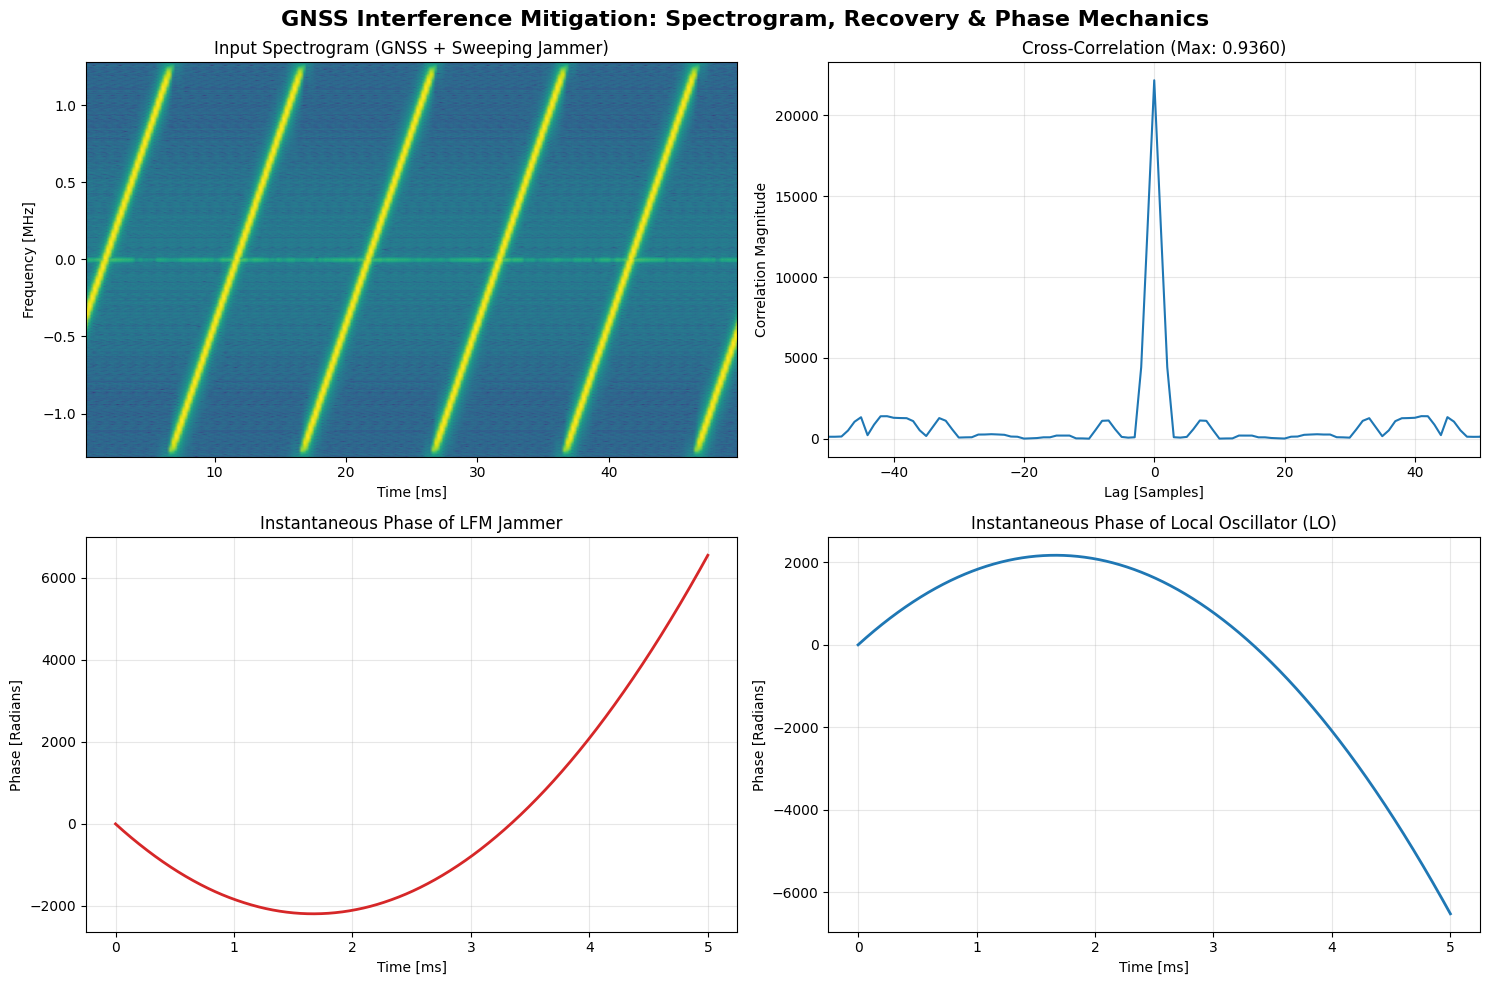

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import spectrogram

# --- Consolidated Pipeline & Phase Mechanics Visualization ---
fig = plt.figure(figsize=(15, 10))

# ---------------------------------------------------------
# Plot 1 (Top Left): Input Spectrogram 
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
f, t, Sxx = spectrogram(acquisition_chunk[ : int(0.05 * f_samplerate)], f_samplerate, nperseg=1024, noverlap=512, return_onesided=False)
f_shifted = np.fft.fftshift(f)
Sxx_shifted = np.fft.fftshift(Sxx, axes=0)
ax1.pcolormesh(t * 1000, f_shifted / 1e6, 10 * np.log10(Sxx_shifted + 1e-15), shading='gouraud', cmap='viridis')
ax1.set_title("Input Spectrogram (GNSS + Sweeping Jammer)")
ax1.set_ylabel("Frequency [MHz]")
ax1.set_xlabel("Time [ms]")

# ---------------------------------------------------------
# Plot 2 (Top Right): Cross-Correlation Peak
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
corr_block_size = int(0.01 * f_samplerate)
corr = np.correlate(reference_clean[:corr_block_size], reference_filtered[:corr_block_size], mode='full')
lags = np.arange(-corr_block_size + 1, corr_block_size)

ax2.plot(lags, np.abs(corr), color='tab:blue', linewidth=1.5)
ax2.set_title(f"Cross-Correlation (Max: {max_correlation:.4f})")
ax2.set_xlabel("Lag [Samples]")
ax2.set_ylabel("Correlation Magnitude")
ax2.set_xlim(-50, 50) # Zoomed in around the zero-lag peak
ax2.grid(True, alpha=0.3)

# ---------------------------------------------------------
# Setup parameters for the Phase plots (Bottom Row)
# ---------------------------------------------------------
vis_len = int(0.005 * f_samplerate)
t_vis = np.arange(vis_len) / f_samplerate * 1000 # Time vector in ms

# Extract the raw jammer signal for this slice
jammer_slice = jammer[start_idx : start_idx + vis_len]

# Re-create the LO for this specific slice using your params
t_local = (start_idx + np.arange(vis_len)) / f_samplerate
LO_slice, _ = JammerSignalProcessor.LO_calculator(
    params.f_start, params.chirp_rate, params.sweep_period, 
    t_local, taper_sec, params.t_sync
)

# Calculate unwrapped phases 
phase_jammer = np.unwrap(np.angle(jammer_slice))
phase_LO = np.unwrap(np.angle(LO_slice))

# ---------------------------------------------------------
# Plot 3 (Bottom Left): Phase of the Jammer
# ---------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
ax3.plot(t_vis, phase_jammer, color='tab:red', lw=2)
ax3.set_title("Instantaneous Phase of LFM Jammer")
ax3.set_ylabel("Phase [Radians]")
ax3.set_xlabel("Time [ms]")
ax3.grid(True, alpha=0.3)

# ---------------------------------------------------------
# Plot 4 (Bottom Right): Phase of the Downconversion LO
# ---------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
ax4.plot(t_vis, phase_LO, color='tab:blue', lw=2)
ax4.set_title("Instantaneous Phase of Local Oscillator (LO)")
ax4.set_ylabel("Phase [Radians]")
ax4.set_xlabel("Time [ms]")
ax4.grid(True, alpha=0.3)

# --- Final Polish ---
fig.suptitle("GNSS Interference Mitigation: Spectrogram, Recovery & Phase Mechanics", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Filtering multiple chunks with 1 parameterization
### The correlation falls off as soon as the accumulated error of the initial parameterization exceeds the width of the static notch.

In [56]:
# -------------------------------------------------------------------------
# SIMULATION SETUP
# -------------------------------------------------------------------------
# Timing and Frequency Configuration
f_samplerate    = 2.56e6
sweep_time      = 10e-3
main_lobe_width = 1.253e6
jammer_freqs    = [-main_lobe_width, main_lobe_width]
chirp_rate      = (jammer_freqs[1] - jammer_freqs[0]) / sweep_time
jitter_std      = 0
jammer_amp_dB   = 80
taper_ratio     = 0.1

# Vectors
N_samples = int(10.0 * f_samplerate)
t_vec     = np.arange(N_samples) / f_samplerate

# Generate the Signal of Interest (GNSS with PRN = 27)
gen = GoldCodeGenerator(PRN=27, samp_rate=f_samplerate, vectorLength=N_samples)
signal_of_interest = gen.process()  

# Generate LFM Jamming signal (Chirp Jammer)
jammer = GoldCodeGenerator.create_linear_FM_signal(
    jammer_freqs, 
    t_vec, 
    f_samplerate, 
    amplitude=10**(jammer_amp_dB/20), 
    chirp_rate  = chirp_rate, 
    jitter_std  = jitter_std, 
    taper_ratio = taper_ratio
)

# Observe the combined signal
signal = signal_of_interest + jammer

print(f"Jammer parameters: \nChirp Rate: {chirp_rate:.2f} Hz/s\nFrequency Range: {jammer_freqs[0]:.2f} to {jammer_freqs[1]:.2f} Hz")

# -------------------------------------------------------------------------
# 1. CHUNKING AND PARAMETERIZATION
# -------------------------------------------------------------------------
acquisition_chunk_size = int(0.5 * f_samplerate) 
start_idx = 26453 # Selected window offset
taper_sec = 0.0002 # 200µs Tukey windowing

# Extract chunk for analysis
acquisition_chunk = signal[start_idx : start_idx + acquisition_chunk_size]

# Parameterization (Includes Sub-Bin Peak Detection & Drift Refinement)
params = JammerSignalProcessor.estimate_jammer_physics(
    acquisition_chunk, 
    f_samplerate, 
    start_idx, 
    taper_sec, 
    spectrogram_nperseg=1024, 
    spectrogram_overlap=819
)

# -------------------------------------------------------------------------
# 2. DESIGNING AN ADAPTIVE NOTCH FILTER
# -------------------------------------------------------------------------
N_taps, notch_width, transition_width_Hz = JammerSignalProcessor.calculate_filter_parameters(
    params.chirp_rate, 
    f_samplerate,
    params.bandwidth,
    notch_width_percentage=0.2,
    transition_width_multiplier=0.1,
    max_phase=1.17
)

attenuation_dB = 81

h = JammerSignalProcessor.dc_firwin_filter(N_taps, f_samplerate, notch_width, attenuation_dB, transition_width_Hz)
group_delay = (N_taps - 1) // 2

print(f"Filter Ready: {N_taps} Taps | Group Delay: {group_delay} samples")

# -------------------------------------------------------------------------
# 3. PROCESSING: Continuous Overlap-Add (OLA) Loop
# -------------------------------------------------------------------------

chunk_size = int(0.02 * f_samplerate) # 20ms processing blocks
tail_length   = N_taps - 1
output_signal = np.zeros(N_samples + tail_length, dtype=complex)

# Telemetry
diag_downconverted = np.zeros(N_samples, dtype=complex)
rolling_corr, rolling_snr, time_stamps = [], [], []


for i_start in tqdm(range(0, N_samples, chunk_size)):
    i_end = min(i_start + chunk_size, N_samples)
    current_length = i_end - i_start
    if current_length == 0: break
    
    full_convolution_length = current_length + tail_length
    signal_chunk  = signal[i_start : i_end]

    # --- Downconversion LO ---
    t_local = (i_start + np.arange(current_length)) / f_samplerate
    LO_down, _ = JammerSignalProcessor.LO_calculator(   
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_local, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # --- Upconversion LO with Group-Delay Compensation ---
    t_up = (i_start - group_delay + np.arange(full_convolution_length)) / f_samplerate
    _, LO_up = JammerSignalProcessor.LO_calculator(
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_up, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # Core DSP Pipeline
    signal_downconverted = signal_chunk * LO_down

    # Filter (Expanding to Full length to capture the ringing tail)
    signal_filtered = fftconvolve(signal_downconverted, h, mode = "full")
    processed_block = signal_filtered * LO_up

    # Overlap-Add: Tail from current chunk sums with the start of the next
    output_signal[i_start : i_start + full_convolution_length] += processed_block
    
    # Diagnostics
    diag_downconverted[i_start:i_end] = signal_downconverted # Capture for spectrogram

    # In-Loop Telemetry (Verify coherence as we go)
    if i_start > 0:
        t_histogram_start = i_start - chunk_size
        clean_slice       = signal_of_interest[t_histogram_start : i_start]
        recovered_slice   = output_signal[t_histogram_start + group_delay : i_start + group_delay]
        
        correlation = JammerSignalProcessor.analyze_correlation(clean_slice, recovered_slice)
        snr  = 10 * np.log10(np.var(clean_slice) / np.var(recovered_slice - clean_slice))
        
        rolling_corr.append(correlation)
        rolling_snr.append(snr)
        time_stamps.append(t_histogram_start / f_samplerate)

# -------------------------------------------------------------------------
# 5. VALIDATION: Final Signal Reconstruction
# -------------------------------------------------------------------------
# Align recovered signal by removing the filter's physical delay
recovered_signal = output_signal[group_delay : N_samples + group_delay]

# Discard edges to avoid filter transient artifacts
safety_margin = N_taps * 2
reference_clean = signal_of_interest[safety_margin : N_samples - safety_margin]
reference_filtered  = recovered_signal[safety_margin : N_samples - safety_margin]

max_correlation = JammerSignalProcessor.analyze_correlation(reference_clean, reference_filtered)

print("========================================================")
print(f"Correlation of chunk starting at idx {start_idx}: {max_correlation:.4f}")
print("========================================================")

Jammer parameters: 
Chirp Rate: 250600000.00 Hz/s
Frequency Range: -1253000.00 to 1253000.00 Hz
Residual Error Detected: Chirp Drift = 248.57 kHz/s
Freq Offset = -23.96 kHz
R² of Fit = 0.9632
Filter Ready: 199 Taps | Group Delay: 99 samples


100%|██████████| 500/500 [00:11<00:00, 43.66it/s]


Correlation of chunk starting at idx 26453: 0.4610


## 2. Notice how the second plot to the right shows the jammer drifting away from the center frequency

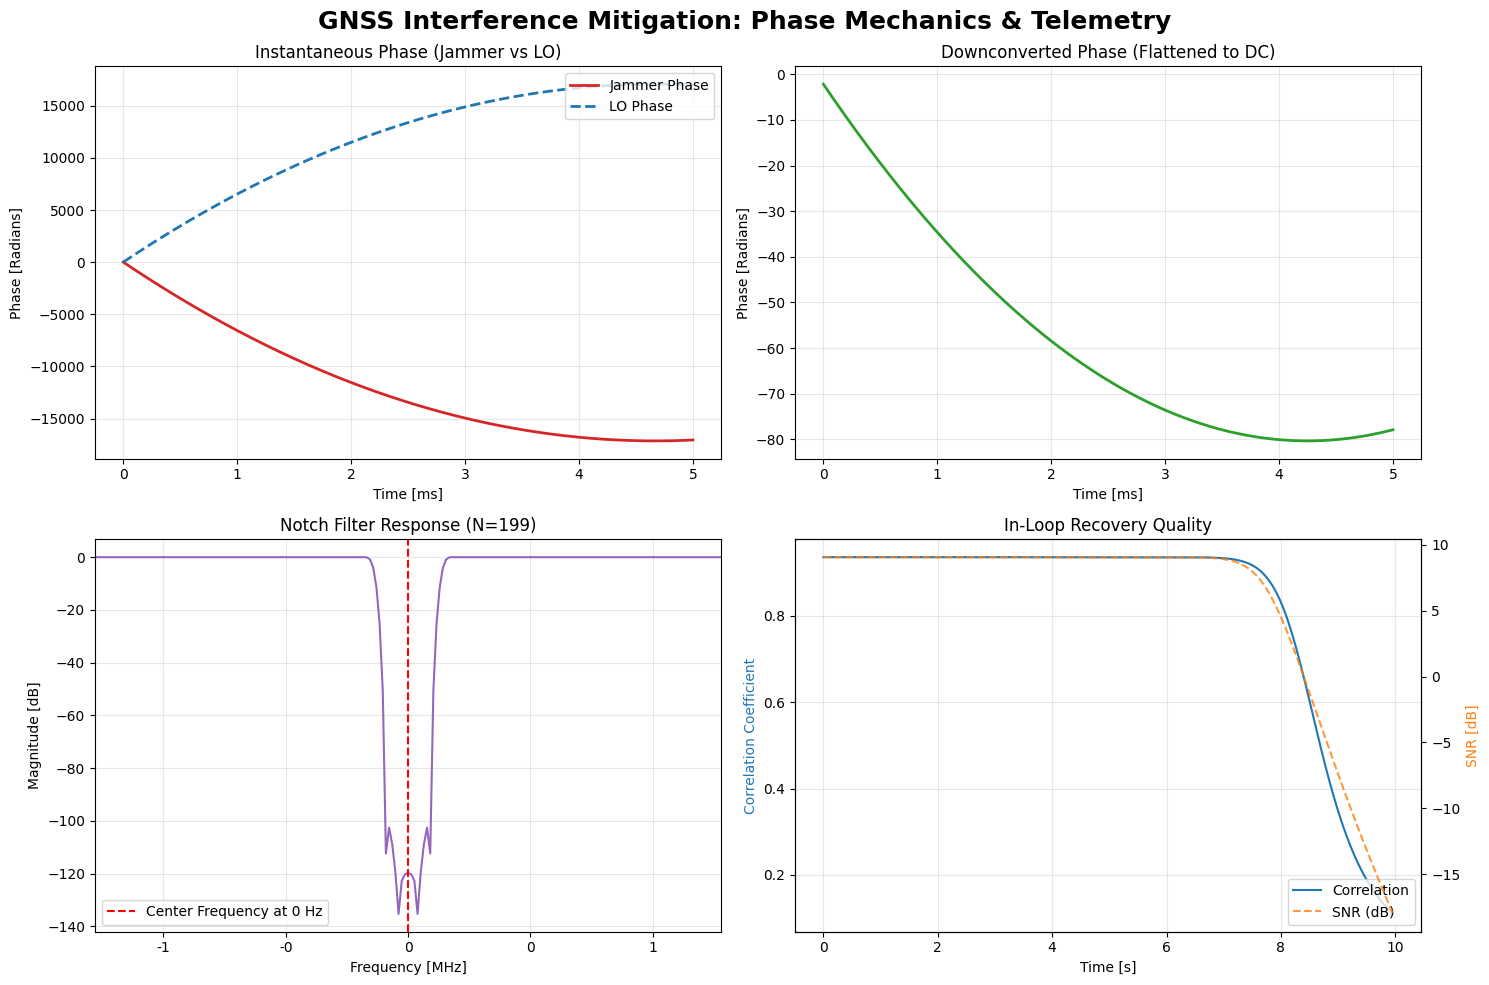

In [58]:
# --- Visualization Setup ---
fig = plt.figure(figsize=(15, 10))
fig.suptitle("GNSS Interference Mitigation: Phase Mechanics & Telemetry", fontsize=18, fontweight='bold')
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# Prepare Phase Information Data
# ---------------------------------------------------------
vis_len = int(0.005 * f_samplerate)
t_vis = np.arange(vis_len) / f_samplerate * 1000 # Time vector in ms

# Extract slices for the phase plots
jammer_slice = jammer[start_idx : start_idx + vis_len]
t_local = (start_idx + np.arange(vis_len)) / f_samplerate
LO_slice, _ = JammerSignalProcessor.LO_calculator(
    params.f_start, params.chirp_rate, params.sweep_period, 
    t_local, taper_sec, params.t_sync
)
downconverted_slice = jammer_slice * LO_slice

# Calculate unwrapped phases
phase_jammer = np.unwrap(np.angle(jammer_slice))
phase_LO = np.unwrap(np.angle(LO_slice))
phase_dc = np.unwrap(np.angle(downconverted_slice))

# ---------------------------------------------------------
# 1. Phase Mechanics (Jammer vs LO)
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
ax1.plot(t_vis, phase_jammer, color='tab:red', label='Jammer Phase', lw=2)
ax1.plot(t_vis, phase_LO, color='tab:blue', linestyle='--', label='LO Phase', lw=2)
ax1.set_title("Instantaneous Phase (Jammer vs LO)")
ax1.set_ylabel("Phase [Radians]")
ax1.set_xlabel("Time [ms]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------
# 2. Downconverted Phase (Flattened)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
ax2.plot(t_vis, phase_dc, color='tab:green', lw=2)
ax2.set_title("Downconverted Phase (Flattened to DC)")
ax2.set_ylabel("Phase [Radians]")
ax2.set_xlabel("Time [ms]")
# ax2.set_ylim(-15, 15) # Zoomed in to show the flattening effect
ax2.grid(True, alpha=0.3)

# ---------------------------------------------------------
# 3. Frequency response of the FIR filter
# ---------------------------------------------------------
f_vec = np.linspace(-f_samplerate/2, f_samplerate/2, N_taps)
MHz_formatter = ticker.FuncFormatter(lambda y, pos: f'{y / 1e6:.0f}')
H = np.fft.fftshift(np.abs(np.fft.fft(h, N_taps)))
H_dB = 20 * np.log10(np.abs(H) + 1e-15)

ax3 = plt.subplot(2, 2, 3)
ax3.plot(f_vec, H_dB, color='tab:purple')
ax3.set_title(f"Notch Filter Response (N={N_taps})")
ax3.set_ylabel("Magnitude [dB]")
ax3.set_xlabel("Frequency [MHz]")
ax3.set_xlim(-f_samplerate/2, f_samplerate/2)
ax3.xaxis.set_major_formatter(MHz_formatter)
ax3.axvline(x=0, color='r', linestyle='--', label='Center Frequency at 0 Hz')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ---------------------------------------------------------
# 4. Telemetry: Rolling Correlation & SNR
# ---------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
ax4_twin = ax4.twinx()

lns1 = ax4.plot(time_stamps, rolling_corr, label='Correlation', color='tab:blue', linewidth=1.5)
lns2 = ax4_twin.plot(time_stamps, rolling_snr, label='SNR (dB)', color='tab:orange', linestyle='--', alpha=0.8)

ax4.set_title("In-Loop Recovery Quality")
ax4.set_xlabel("Time [s]")
ax4.set_ylabel("Correlation Coefficient", color='tab:blue')
ax4_twin.set_ylabel("SNR [dB]", color='tab:orange')

# Set y limits for both axes
# ax4.set_ylim(0.7, 1)                
# ax4_twin.set_ylim(0, 10)   

# Legend handling for twin axes
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax4.legend(lns, labs, loc='lower right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Final Adaptive Notch filter (in-loop parameterization)
#### Every 1 second, the in-loop parameterization scans the telemetry data for any error (drift) in the jammer and adjusts.

In [43]:
# -------------------------------------------------------------------------
# SIMULATION SETUP
# -------------------------------------------------------------------------
# Timing and Frequency Configuration
f_samplerate    = 2.56e6
sweep_time      = 10e-3
main_lobe_width = 1.253e6
jammer_freqs    = [-main_lobe_width, main_lobe_width]
chirp_rate      = (jammer_freqs[1] - jammer_freqs[0]) / sweep_time
jitter_std      = 1e3
jammer_amp_dB   = 80
taper_ratio     = 0.1

# Vectors
N_samples = int(10.0 * f_samplerate)
t_vec     = np.arange(N_samples) / f_samplerate

# Generate the Signal of Interest (GNSS with PRN = 27)
gen = GoldCodeGenerator(PRN=27, samp_rate=f_samplerate, vectorLength=N_samples)
signal_of_interest = gen.process()  

# Generate LFM Jamming signal (Chirp Jammer)
jammer = GoldCodeGenerator.create_linear_FM_signal(
    jammer_freqs, 
    t_vec, 
    f_samplerate, 
    amplitude=10**(jammer_amp_dB/20), 
    chirp_rate  = chirp_rate, 
    jitter_std  = jitter_std, 
    taper_ratio = taper_ratio
)

# Observe the combined signal
signal = signal_of_interest + jammer

print(f"Jammer parameters: \nChirp Rate: {chirp_rate:.2f} Hz/s\nFrequency Range: {jammer_freqs[0]:.2f} to {jammer_freqs[1]:.2f} Hz")

# -------------------------------------------------------------------------
# 1. CHUNKING AND PARAMETERIZATION
# -------------------------------------------------------------------------
acquisition_chunk_size = int(0.5 * f_samplerate) 
start_idx = 26453 # Selected window offset
taper_sec = 0.0002 # 200µs Tukey windowing

# Extract chunk for analysis
acquisition_chunk = signal[start_idx : start_idx + acquisition_chunk_size]

# Parameterization (Includes Sub-Bin Peak Detection & Drift Refinement)
params = JammerSignalProcessor.estimate_jammer_physics(
    acquisition_chunk, 
    f_samplerate, 
    start_idx, 
    taper_sec, 
    spectrogram_nperseg=1024, 
    spectrogram_overlap=819
)

# -------------------------------------------------------------------------
# 2. DESIGNING AN ADAPTIVE NOTCH FILTER
# -------------------------------------------------------------------------
N_taps, notch_width, transition_width_Hz = JammerSignalProcessor.calculate_filter_parameters(
    params.chirp_rate, 
    f_samplerate,
    params.bandwidth,
    notch_width_percentage=0.2,
    transition_width_multiplier=0.1,
    max_phase=1.17
)

attenuation_dB = 81

h = JammerSignalProcessor.dc_firwin_filter(N_taps, f_samplerate, notch_width, attenuation_dB, transition_width_Hz)
group_delay = (N_taps - 1) // 2

print(f"Filter Ready: {N_taps} Taps | Group Delay: {group_delay} samples")

# -------------------------------------------------------------------------
# 3. PROCESSING: Continuous Overlap-Add (OLA) Loop
# -------------------------------------------------------------------------

chunk_size = int(0.02 * f_samplerate) # 20ms processing blocks
tail_length   = N_taps - 1
output_signal = np.zeros(N_samples + tail_length, dtype=complex)

# Telemetry
diag_downconverted = np.zeros(N_samples, dtype=complex)
rolling_corr, rolling_snr, time_stamps = [], [], []

# --- Tracking Initializations ---
current_phase_offset = 0.0
tracking_interval_samples = int(1.0 * f_samplerate) # Track drift every 1.0 seconds

for i_start in tqdm(range(0, N_samples, chunk_size)):
    i_end = min(i_start + chunk_size, N_samples)
    current_length = i_end - i_start
    if current_length == 0: break
    
    full_convolution_length = current_length + tail_length
    signal_chunk  = signal[i_start : i_end]

    # =====================================================================
    # THE BLOCK TRACKER (Executes once per second to kill drift)
    # =====================================================================
    if i_start > 0 and i_start % tracking_interval_samples == 0:
        
        # 1. Grab 1-second telemetry block
        recent_residual = diag_downconverted[i_start - tracking_interval_samples : i_start]
        
        # 2. Inline Sub-Bin Spectrogram to measure drift slant
        f_axis, t_axis, Sxx = spectrogram(recent_residual, fs=f_samplerate, nperseg=1024, noverlap=800, return_onesided=False)
        max_indices = np.argmax(Sxx, axis=0)
        f_res = f_axis[max_indices]
        
        bin_width = f_axis[1] - f_axis[0]
        for idx, k in enumerate(max_indices):
            if 0 < k < len(f_axis) - 1:
                left, center, right = Sxx[k-1, idx], Sxx[k, idx], Sxx[k+1, idx]
                denom = left - 2*center + right
                if denom != 0:
                    f_res[idx] += (0.5 * (left - right) / denom) * bin_width
                    
        f_res_unwrapped = np.unwrap(f_res * 2 * np.pi / f_samplerate) * f_samplerate / (2 * np.pi)
        delta_k, delta_f_start, _, _, _ = stats.linregress(t_axis, f_res_unwrapped)
        
        # 3. Calculate Phase Continuity Hand-off
        t_boundary = i_start / f_samplerate
        t_aligned = t_boundary - params.t_sync
        
        cycle_number = int(np.floor(t_aligned / params.sweep_period))
        t_in_sweep = t_aligned - (cycle_number * params.sweep_period)
        
        # Where the old LO phase is resting right now
        old_phase = (params.f_start * t_in_sweep) + (0.5 * params.chirp_rate * t_in_sweep**2) + \
                    (cycle_number * (params.f_start * params.sweep_period + 0.5 * params.chirp_rate * params.sweep_period**2)) + \
                    current_phase_offset
                    
        # 4. Update the Parameters safely
        params.chirp_rate += delta_k
        params.f_start += delta_f_start
        params.sweep_period = params.bandwidth / abs(params.chirp_rate)
        
        # 5. Calculate where the NEW LO would be, and find the difference
        new_cycle_number = int(np.floor(t_aligned / params.sweep_period))
        new_t_in_sweep = t_aligned - (new_cycle_number * params.sweep_period)
        
        new_phase_raw = (params.f_start * new_t_in_sweep) + (0.5 * params.chirp_rate * new_t_in_sweep**2) + \
                        (new_cycle_number * (params.f_start * params.sweep_period + 0.5 * params.chirp_rate * params.sweep_period**2))
        
        # Save the difference so we can permanently bridge the gap
        current_phase_offset = old_phase - new_phase_raw
    # =====================================================================

    # --- Downconversion LO ---
    t_local = (i_start + np.arange(current_length)) / f_samplerate
    LO_down, _ = JammerSignalProcessor.LO_calculator(   
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_local, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # --- Upconversion LO with Group-Delay Compensation ---
    t_up = (i_start - group_delay + np.arange(full_convolution_length)) / f_samplerate
    _, LO_up = JammerSignalProcessor.LO_calculator(
                                                    params.f_start, 
                                                    params.chirp_rate, 
                                                    params.sweep_period,
                                                    t_up, 
                                                    taper_sec, 
                                                    params.t_sync
                                                    )

    # Apply Block-Tracking Phase Continuity Offset directly to the LO arrays
    phase_correction = np.exp(-1j * 2 * np.pi * current_phase_offset)
    LO_down *= phase_correction
    LO_up *= np.conj(phase_correction)

    # Core DSP Pipeline
    signal_downconverted = signal_chunk * LO_down

    # Filter (Expanding to Full length to capture the ringing tail)
    signal_filtered = fftconvolve(signal_downconverted, h, mode = "full")
    processed_block = signal_filtered * LO_up

    # Overlap-Add: Tail from current chunk sums with the start of the next
    output_signal[i_start : i_start + full_convolution_length] += processed_block
    
    # Diagnostics
    diag_downconverted[i_start:i_end] = signal_downconverted # Capture for spectrogram

    # In-Loop Telemetry (Verify coherence as we go)
    if i_start > 0:
        t_histogram_start = i_start - chunk_size
        clean_slice       = signal_of_interest[t_histogram_start : i_start]
        recovered_slice   = output_signal[t_histogram_start + group_delay : i_start + group_delay]
        
        correlation = JammerSignalProcessor.analyze_correlation(clean_slice, recovered_slice)
        snr  = 10 * np.log10(np.var(clean_slice) / np.var(recovered_slice - clean_slice))
        
        rolling_corr.append(correlation)
        rolling_snr.append(snr)
        time_stamps.append(t_histogram_start / f_samplerate)

# -------------------------------------------------------------------------
# 5. VALIDATION: Final Signal Reconstruction
# -------------------------------------------------------------------------
# Align recovered signal by removing the filter's physical delay
recovered_signal = output_signal[group_delay : N_samples + group_delay]

# Discard edges to avoid filter transient artifacts
safety_margin = N_taps * 2
reference_clean = signal_of_interest[safety_margin : N_samples - safety_margin]
reference_filtered  = recovered_signal[safety_margin : N_samples - safety_margin]

max_correlation = JammerSignalProcessor.analyze_correlation(reference_clean, reference_filtered)

print("========================================================")
print(f"Correlation of chunk starting at idx {start_idx}: {max_correlation:.4f}")
print("========================================================")

Jammer parameters: 
Chirp Rate: 250600000.00 Hz/s
Frequency Range: -1253000.00 to 1253000.00 Hz
Residual Error Detected: Chirp Drift = 248.70 kHz/s
Freq Offset = -24.58 kHz
R² of Fit = 0.9541
Filter Ready: 201 Taps | Group Delay: 100 samples


100%|██████████| 500/500 [00:15<00:00, 31.31it/s]


Correlation of chunk starting at idx 26453: 0.9359


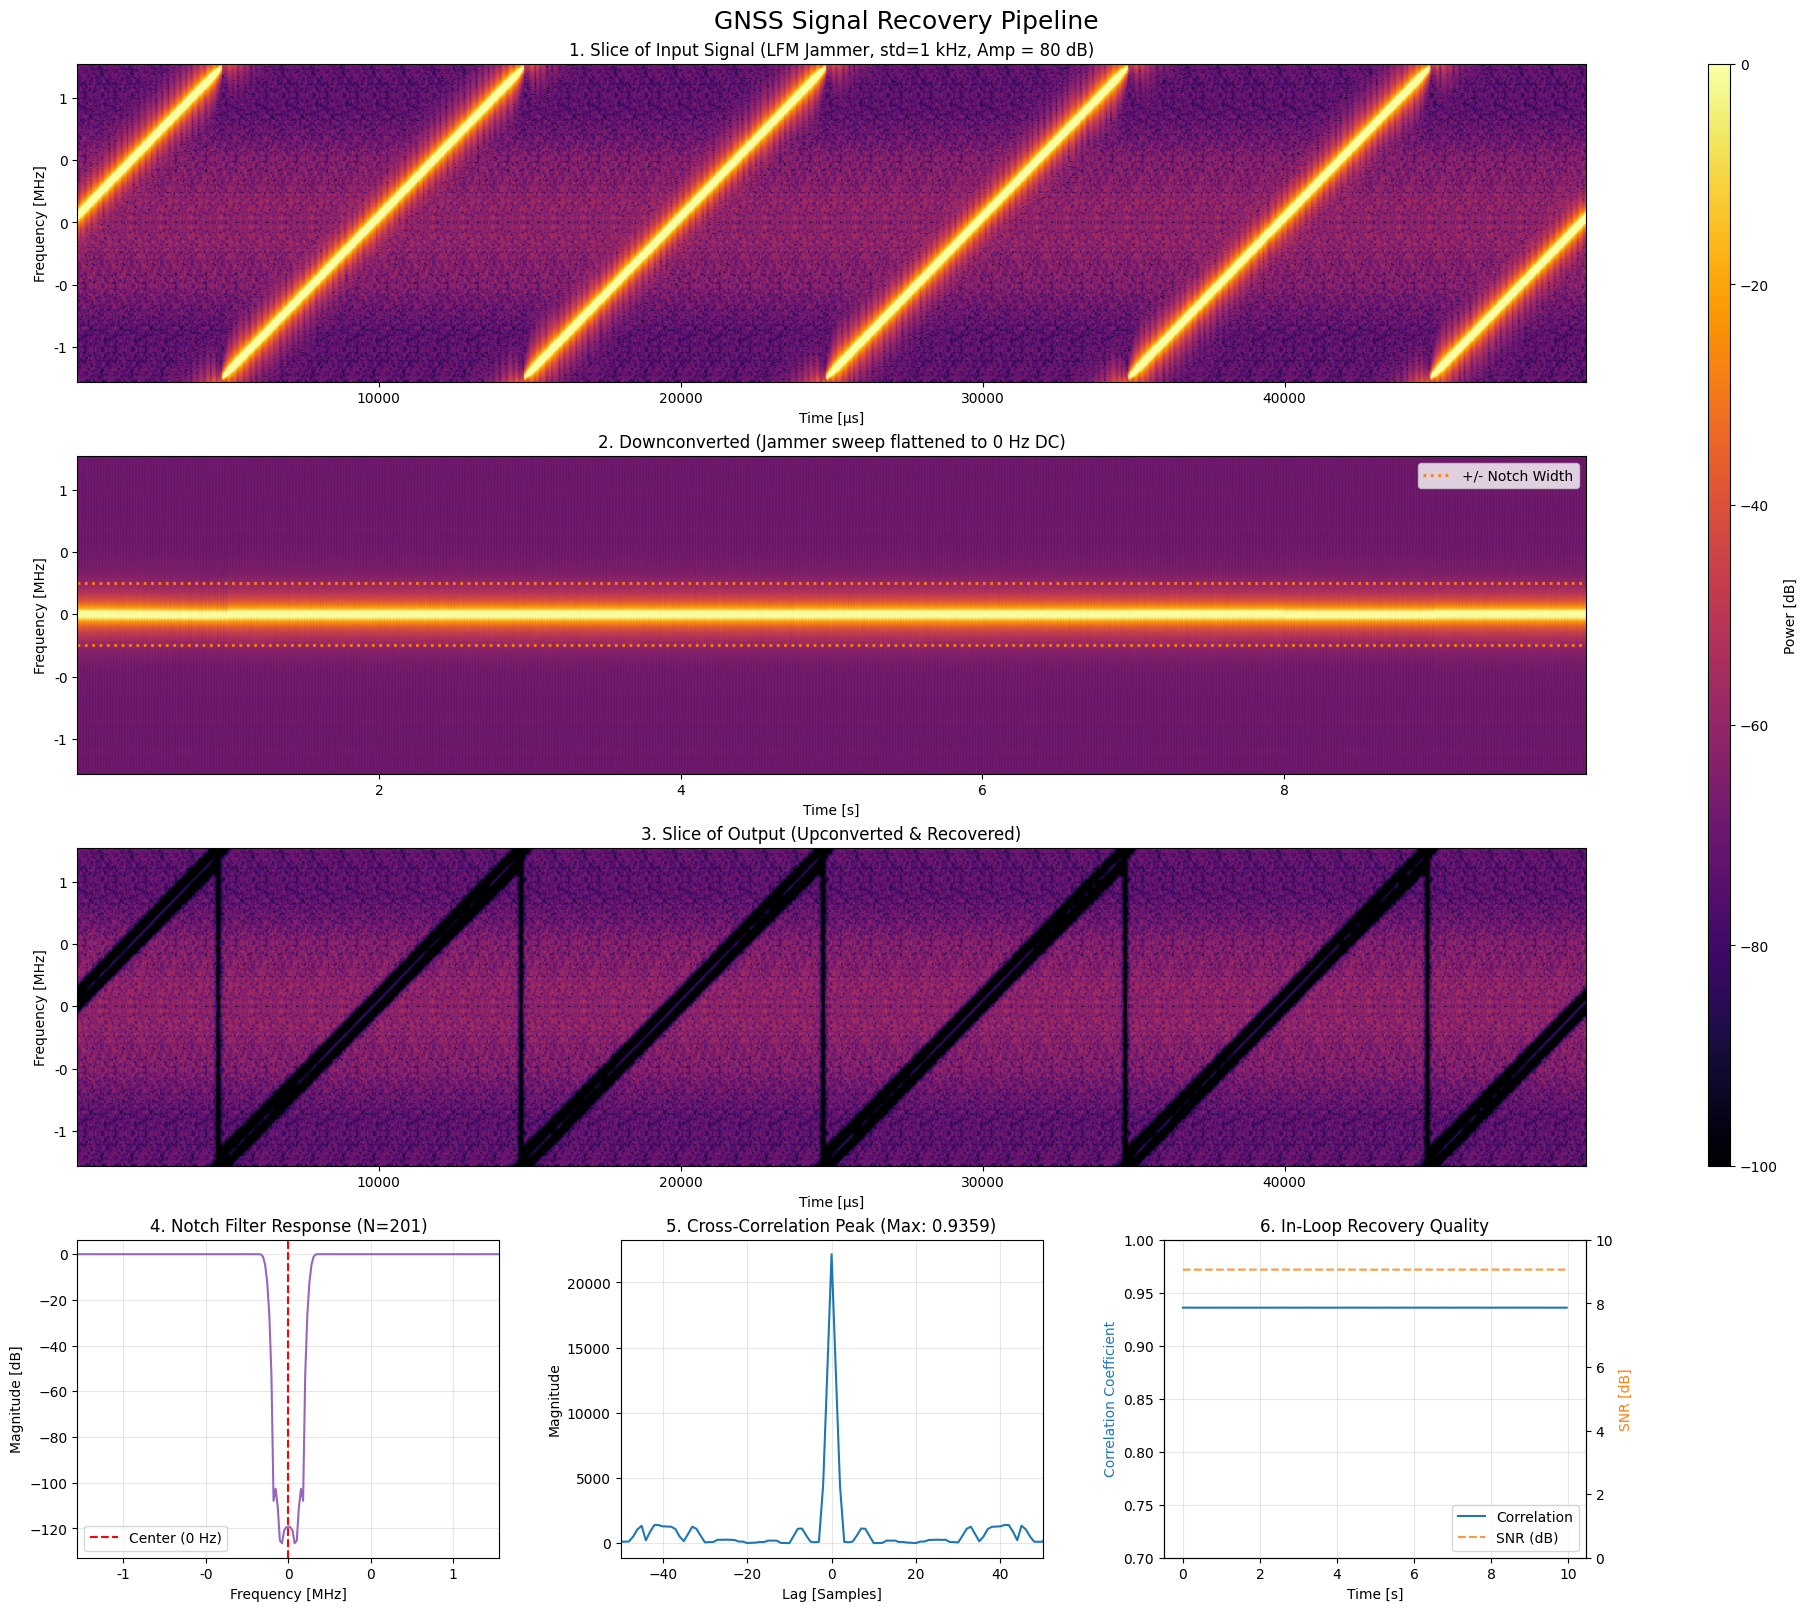

In [52]:
# 1. Define the grid layout
# We use 4 rows to keep the spectrograms wide and fit the diagnostics at the bottom.
layout = [
    ['Top1', 'Top1', 'Top1'],
    ['Top2', 'Top2', 'Top2'],
    ['Top3', 'Top3', 'Top3'],
    ['P1_Filt', 'P1_Corr', 'P1_Telemetry']
]

# 2. Create the figure (increased height to accommodate the 4th row)
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 16), constrained_layout=True, dpi=100)

# Common plotting parameters for spectrograms
NFFT = 256
noverlap = 128
cmap = 'inferno'
vmin = -100
vmax = 0
us_formatter = ticker.FuncFormatter(lambda x, pos: f'{x * 1e6:.0f}')
MHz_formatter = ticker.FuncFormatter(lambda y, pos: f'{y / 1e6:.0f}')

# ---------------------------------------------------------
# ROW 1: Original Input Spectrogram
# ---------------------------------------------------------
ax = axes['Top1']
P, freqs, bins, im = ax.specgram(signal[int(f_samplerate) - 12345: int(1.05 * f_samplerate) - 12345], NFFT=NFFT, Fs=f_samplerate, noverlap=noverlap, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_title(f"1. Slice of Input Signal (LFM Jammer, std={jitter_std/1000:.0f} kHz, Amp = {jammer_amp_dB:.0f} dB)")
ax.set_ylabel("Frequency [MHz]")
ax.set_xlabel("Time [μs]")
ax.xaxis.set_major_formatter(us_formatter)
ax.yaxis.set_major_formatter(MHz_formatter)

# ---------------------------------------------------------
# ROW 2: Downconverted Spectrogram
# ---------------------------------------------------------
ax = axes['Top2']
P, freqs, bins, im = ax.specgram(diag_downconverted, NFFT=NFFT, Fs=f_samplerate, noverlap=noverlap, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_title("2. Downconverted (Jammer sweep flattened to 0 Hz DC)")
ax.set_ylabel("Frequency [MHz]")
ax.set_xlabel("Time [s]")
ax.axhline(y=notch_width, color='tab:orange', linestyle=':', linewidth=2, label='+/- Notch Width')
ax.axhline(y=-notch_width, color='tab:orange', linestyle=':', linewidth=2)
# ax.xaxis.set_major_formatter(us_formatter)
ax.yaxis.set_major_formatter(MHz_formatter)
ax.legend(loc='upper right')

# ---------------------------------------------------------
# ROW 3: Output Spectrogram (Recovered Signal)
# ---------------------------------------------------------
ax = axes['Top3']
P, freqs, bins, im = ax.specgram(recovered_signal[int(f_samplerate) - 12345 : int(1.05 * f_samplerate) - 12345], NFFT=NFFT, Fs=f_samplerate, noverlap=noverlap, cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_title("3. Slice of Output (Upconverted & Recovered)")
ax.set_ylabel("Frequency [MHz]")
ax.set_xlabel("Time [μs]")
ax.xaxis.set_major_formatter(us_formatter)
ax.yaxis.set_major_formatter(MHz_formatter)

# Add a single colorbar for all three spectrogram rows
spec_axes = [axes['Top1'], axes['Top2'], axes['Top3']]
fig.colorbar(im, ax=spec_axes, label='Power [dB]', location='right', aspect=50)

# =========================================================
# BOTTOM ROW: Validation & Diagnostics
# =========================================================

# Plot 4: Adaptive Notch Filter Response
ax = axes['P1_Filt']
f_vec = np.linspace(-f_samplerate/2, f_samplerate/2, N_taps)
H = np.fft.fftshift(np.abs(np.fft.fft(h, N_taps)))
H_dB = 20 * np.log10(np.abs(H) + 1e-15)

ax.plot(f_vec, H_dB, color='tab:purple')
ax.set_title(f"4. Notch Filter Response (N={N_taps})")
ax.set_ylabel("Magnitude [dB]")
ax.set_xlabel("Frequency [MHz]")
ax.set_xlim(-f_samplerate/2, f_samplerate/2)
ax.xaxis.set_major_formatter(MHz_formatter)
ax.axvline(x=0, color='r', linestyle='--', label='Center (0 Hz)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Cross-Correlation Validation
ax = axes['P1_Corr']
corr_block_size = int(0.01 * f_samplerate)
corr = np.correlate(reference_clean[:corr_block_size], reference_filtered[:corr_block_size], mode='full')
lags = np.arange(-corr_block_size + 1, corr_block_size)

ax.plot(lags, np.abs(corr), color='tab:blue', linewidth=1.5)
ax.set_title(f"5. Cross-Correlation Peak (Max: {max_correlation:.4f})")
ax.set_xlabel("Lag [Samples]")
ax.set_ylabel("Magnitude")
ax.set_xlim(-50, 50) 
ax.grid(True, alpha=0.3)

# Plot 6: Telemetry (Rolling Correlation & SNR)
ax = axes['P1_Telemetry']
ax_twin = ax.twinx()

lns1 = ax.plot(time_stamps, rolling_corr, label='Correlation', color='tab:blue', linewidth=1.5)
lns2 = ax_twin.plot(time_stamps, rolling_snr, label='SNR (dB)', color='tab:orange', linestyle='--', alpha=0.8)

ax.set_title("6. In-Loop Recovery Quality")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Correlation Coefficient", color='tab:blue')
ax_twin.set_ylabel("SNR [dB]", color='tab:orange')

# Set y limits for both axes
ax.set_ylim(0.7, 1)                
ax_twin.set_ylim(0, 10)          

# Legend handling for twin axes
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')
ax.grid(True, alpha=0.3)

# Final Title
fig.suptitle(f"GNSS Signal Recovery Pipeline", fontsize=18)

plt.show()